# `ensure_positive_ndt` makes LAN likelihoods discontinuous in `t` — which is why the hierarchical LAN DDM fails to converge

**Summary.** HSSM replaces a trial's log-likelihood with `LOGP_LB = -66.1` whenever
`rt - t <= 1e-15` (`ensure_positive_ndt` in `src/hssm/distribution_utils/dist.py`). It then
mixes in the default lapse distribution (`p_outlier = 0.05`, `Uniform(0, 20)`), which puts a
floor of `log(0.05 / 20) = -5.99` under every trial.

- **Analytical DDM: the guard does nothing.** By the time `t` reaches `rt`, the true density
  has already collapsed to about `e^-67`. After the mixture that trial already sits on the
  floor, so overwriting it changes nothing.
- **LAN DDM (`ddm.onnx`): the guard creates a jump.** The network cannot represent the density
  collapsing to zero at `rt = t`. It levels off at a finite value — between about -16 and
  -3.5 over the parameter grid in §5 — which is often not far below the lapse floor, and
  sometimes above it. The guard then drops that live value onto the floor, producing a **jump
  discontinuity in the log-posterior as a function of `t`**. Its size depends on the
  parameters: from about 0 to over 2 log units per trial (median 0.09 over the §5 grid), and
  0.39–0.64 at the three fastest RTs of one subject in this dataset (§6).
- **NUTS cannot integrate across a jump.** Step-size adaptation shrinks the step until
  crossings become rare. On James' 44-subject dataset the guarded LAN run ends with step size
  7.6e-4, every draw hits `max_tree_depth = 10`, `r_hat` is 1.70 and the minimum ESS is 6 —
  with **zero divergences**, so the standard warning never fires.
- **Removing only the guard fixes sampling.** Patching `ensure_positive_ndt` to the identity
  and changing nothing else restores `r_hat` 1.02, ESS 301 and step size 0.12, and recovers
  essentially the analytical posterior.

Removing the guard is a **diagnostic, not a fix** — see §8.

## The three runs

| label | file in `idata/` | `loglik_kind` | `ensure_positive_ndt` |
|---|---|---|---|
| analytical | `idata_real_analytical_log_logit_nativebounds_thierarchical_noncentred_vdiffz.nc` | `analytical` | on (default) |
| LAN, guard on | `idata_real_approx_differentiable_log_logit_nativebounds_thierarchical_noncentred_vdiffz.nc` | `approx_differentiable` | on (default) |
| LAN, guard off | `idata_real_approx_differentiable_log_logit_nativebounds_thierarchical_noncentred_vdiffz_noguard.nc` | `approx_differentiable` | **patched to identity** |

Everything else is identical across the three:

- **Data:** `ddm_ladder_real_data.csv` — 8,427 trials from 44 subjects.
- **Model:** `v ~ 1 + vdiff + (1 + vdiff | participant_id)` and
  `{a, z, t} ~ 1 + (1 | participant_id)`, non-centred, `link_settings="log_logit"`,
  `vdiff` z-scored, explicit priors stated in parameter units.
- **Sampler:** numpyro NUTS, 4 chains, 1000 tune / 1000 draws, `target_accept = 0.8`,
  `max_tree_depth = 10`.
- **Lapse:** `p_outlier` and the lapse distribution left at HSSM defaults.

The runs were produced with the script in this folder:

```bash
python "ddm_mre_hierarchical_james (1).py" --data real --lik analytical            --links log_logit --zscore-vdiff
python "ddm_mre_hierarchical_james (1).py" --data real --lik approx_differentiable --links log_logit --zscore-vdiff
python "ddm_mre_hierarchical_james (1).py" --data real --lik approx_differentiable --links log_logit --zscore-vdiff --no-ndt-guard
```

`--no-ndt-guard` rebinds `hssm.distribution_utils.dist.ensure_positive_ndt` to
`lambda data, logp, list_params, dist_params: logp` before the model is built.

The runs were made on an earlier commit (`eae1a600`). Between that commit and this branch,
the only change to `distribution_utils/dist.py`, `likelihoods/analytical.py`,
`distribution_utils/onnx.py` and `modelconfig/ddm_config.py` is a docstring edit, so the code
evaluated below is the code that ran.

## Contents

1. Setup
2. Convergence diagnostics
3. Posterior estimates across the three runs
4. Where the guard sits in HSSM's log-likelihood
5. `logp` as `t` approaches `rt` — one trial
6. `logp` as `t` approaches `rt` — one subject from this dataset, at the fitted posterior
7. Why a jump stalls NUTS, and how much this dataset is exposed to it
8. Summary for developers

## 1. Setup

In [1]:
import inspect
import os
import subprocess
import warnings
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")   # nothing here needs a GPU
warnings.filterwarnings("ignore", message=".*Numba will use object mode.*")

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt

import hssm
import hssm.distribution_utils.dist as hssm_dist
from hssm.defaults import INITVAL_SETTINGS
from hssm.modelconfig.ddm_config import get_ddm_config

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

HERE = Path.cwd()
if not (HERE / "idata").exists() and (HERE / "ddm_ndt_scripts" / "idata").exists():
    HERE = HERE / "ddm_ndt_scripts"

RUNS = {
    "analytical": "idata_real_analytical_log_logit_nativebounds_thierarchical_noncentred_vdiffz.nc",
    "LAN, guard on": "idata_real_approx_differentiable_log_logit_nativebounds_thierarchical_noncentred_vdiffz.nc",
    "LAN, guard off": "idata_real_approx_differentiable_log_logit_nativebounds_thierarchical_noncentred_vdiffz_noguard.nc",
}
LOGLIK_KIND = {"analytical": "analytical",
               "LAN, guard on": "approx_differentiable",
               "LAN, guard off": "approx_differentiable"}
COLOR = {"analytical": "#4C72B0", "LAN, guard on": "#DD8452", "LAN, guard off": "#55A868"}

commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], cwd=HERE,
                        capture_output=True, text=True).stdout.strip()
print(f"HSSM source : {Path(hssm.__file__).parent}  (git {commit or 'unknown'})")
print(f"pymc {pm.__version__} | pytensor {pytensor.__version__} | arviz {az.__version__}")

# ---- data, exactly as the runs prepared it --------------------------------
data = pd.read_csv(HERE / "ddm_ladder_real_data.csv")
data["participant_id"] = data.participant_id.astype(int).astype(str)
VDIFF_MU, VDIFF_SD = data.vdiff.mean(), data.vdiff.std(ddof=0)
data["vdiff_z"] = (data.vdiff - VDIFF_MU) / VDIFF_SD          # --zscore-vdiff
SUBJECTS = sorted(data.participant_id.unique(), key=int)
print(f"\ndata: {len(data)} trials, {len(SUBJECTS)} subjects, "
      f"rt {data.rt.min():.3f}–{data.rt.max():.3f} s (median {data.rt.median():.3f})")

# ---- the three runs --------------------------------------------------------
idata = {run: az.from_netcdf(HERE / "idata" / fname) for run, fname in RUNS.items()}
for run, d in idata.items():
    same = np.array_equal(np.asarray(d.observed_data["rt,response"].values),
                          data[["rt", "response"]].to_numpy(float))
    attrs = d.posterior.attrs
    print(f"{run:15} {d.posterior.sizes['chain']} chains x {d.posterior.sizes['draw']} draws"
          f" | created {str(attrs.get('created_at', '?'))[:19]} UTC"
          f" | observed data == csv: {same}")

# ---- link functions: each run's own, from its likelihood's bounds ----------
BOUNDS = {run: get_ddm_config()["likelihoods"][kind]["bounds"]
          for run, kind in LOGLIK_KIND.items()}


def link_of(bounds):
    """Same dispatch as RegressionParam.set_loglogit_link (param/regression_param.py)."""
    lo, hi = bounds
    if np.isneginf(lo) and np.isposinf(hi):
        return "identity"
    if lo == 0.0 and np.isposinf(hi):
        return "log"
    return "gen_logit"


def inv_link(eta, bounds):
    lo, hi = bounds
    kind = link_of(bounds)
    if kind == "identity":
        return eta
    if kind == "log":
        return np.exp(eta)
    return lo + (hi - lo) / (1.0 + np.exp(-eta))


def dparam_deta(x, bounds):
    """d(parameter) / d(linear predictor), evaluated at parameter value x."""
    lo, hi = bounds
    kind = link_of(bounds)
    if kind == "identity":
        return np.ones_like(x)
    if kind == "log":
        return x
    u = (x - lo) / (hi - lo)
    return (hi - lo) * u * (1.0 - u)


print("\nlinks induced by log_logit:")
for run in ("analytical", "LAN, guard on"):
    print(f"  {run:15}" + "  ".join(f"{p}: {link_of(BOUNDS[run][p])} {BOUNDS[run][p]}"
                                    for p in "vazt"))

HSSM source : /oscar/data/frankmj/azhang/HSSMSpine/repos/HSSM/src/hssm  (git ee08643a)
pymc 6.2.0 | pytensor 3.2.2 | arviz 1.2.0

data: 8427 trials, 44 subjects, rt 0.516–5.983 s (median 1.567)
analytical      4 chains x 1000 draws | created 2026-09-05T02:30:20 UTC | observed data == csv: True
LAN, guard on   4 chains x 1000 draws | created 2026-09-05T03:07:28 UTC | observed data == csv: True
LAN, guard off  4 chains x 1000 draws | created 2026-09-09T19:43:19 UTC | observed data == csv: True

links induced by log_logit:
  analytical     v: identity (-inf, inf)  a: log (0.0, inf)  z: gen_logit (0.0, 1.0)  t: log (0.0, inf)
  LAN, guard on  v: gen_logit (-3.0, 3.0)  a: gen_logit (0.3, 2.5)  z: gen_logit (0.0, 1.0)  t: gen_logit (0.0, 2.0)


## 2. Convergence diagnostics

Statistics come from each file's `sample_stats` group, plus `az.summary` over every
parameter in the posterior (group-level terms and all 44 subject offsets).

In [2]:
SUMMARY, rows = {}, {}
for run, d in idata.items():
    s = az.summary(d, round_to="none")
    SUMMARY[run] = s
    ss = d.sample_stats
    tree = np.asarray(ss.tree_depth.values)
    rows[run] = [
        f"{s.r_hat.max():.3f}",
        f"{int((s.r_hat > 1.01).sum())} / {len(s)}",
        f"{s.ess_bulk.min():.0f}",
        f"{s.ess_tail.min():.0f}",
        f"{s.ess_bulk.median():.0f}",
        f"{np.asarray(ss.step_size.values)[:, -1].mean():.2e}",
        f"{tree.mean():.2f}",
        f"{(tree >= 10).mean():.0%}",
        f"{np.asarray(ss.n_steps.values).mean():.0f}",
        f"{int(np.asarray(ss.diverging.values).sum())}",
        f"{np.asarray(ss.acceptance_rate.values).mean():.3f}",
        f"{float(d.posterior.attrs['sampling_time']) / 60:.1f}",
    ]
index = ["max r_hat", "parameters with r_hat > 1.01", "min ess_bulk", "min ess_tail",
         "median ess_bulk", "step size after warmup", "mean tree depth",
         "draws at max_tree_depth (10)", "leapfrog steps per draw", "divergences",
         "mean acceptance", "sampling time (min)"]
print(pd.DataFrame(rows, index=index).to_string())

group_terms = [n for n in SUMMARY["LAN, guard on"].index if "[" not in n]
print("\nLAN, guard on — group-level terms, worst r_hat first (link scale):")
print(SUMMARY["LAN, guard on"].loc[group_terms, ["mean", "sd", "ess_bulk", "ess_tail", "r_hat"]]
      .sort_values("r_hat", ascending=False).round(3).to_string())

                             analytical LAN, guard on LAN, guard off
max r_hat                         1.022         1.699          1.019
parameters with r_hat > 1.01   19 / 450     450 / 450        8 / 450
min ess_bulk                        227             6            301
min ess_tail                        318             7            423
median ess_bulk                    1925            51           2394
step size after warmup         1.09e-01      7.60e-04       1.24e-01
mean tree depth                    5.05         10.00           5.01
draws at max_tree_depth (10)         0%          100%             0%
leapfrog steps per draw              33          1023             31
divergences                           0             0              0
mean acceptance                   0.912         0.804          0.910
sampling time (min)                 1.4          39.1            2.9

LAN, guard on — group-level terms, worst r_hat first (link scale):
                               mean

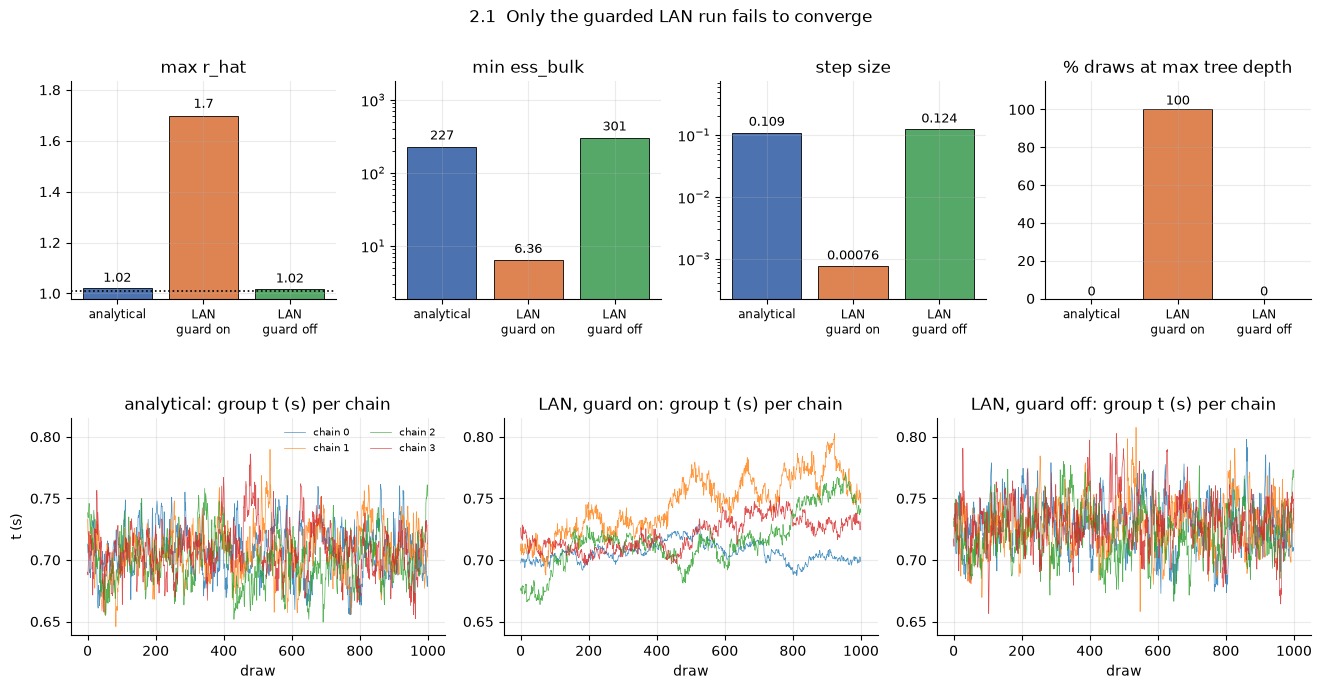

In [3]:
fig = plt.figure(figsize=(16, 7.2))
grid = fig.add_gridspec(2, 12, hspace=0.55, wspace=1.2)
order = list(RUNS)
labels = [r.replace(", ", "\n") for r in order]

def stat(run, what):
    s, ss = SUMMARY[run], idata[run].sample_stats
    return {"max r_hat": s.r_hat.max(),
            "min ess_bulk": s.ess_bulk.min(),
            "step size": np.asarray(ss.step_size.values)[:, -1].mean(),
            "% draws at max tree depth": 100 * (np.asarray(ss.tree_depth.values) >= 10).mean()}[what]

for i, (what, log) in enumerate([("max r_hat", False), ("min ess_bulk", True),
                                 ("step size", True), ("% draws at max tree depth", False)]):
    ax = fig.add_subplot(grid[0, 3 * i:3 * i + 3])
    vals = [stat(r, what) for r in order]
    bars = ax.bar(range(3), vals, color=[COLOR[r] for r in order], edgecolor="k", lw=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v * (1.15 if log else 1.01) + (0 if log else 0.002),
                f"{v:.3g}", ha="center", va="bottom", fontsize=9)
    if log:
        ax.set_yscale("log")
        ax.set_ylim(min(vals) * 0.3, max(vals) * 6)
    if what == "max r_hat":
        ax.axhline(1.01, color="k", ls=":", lw=1.2)
        ax.set_ylim(0.98, max(vals) * 1.08)
    if what.startswith("%"):
        ax.set_ylim(0, 115)
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels, fontsize=8.5)
    ax.set_title(what)

# group-level t, per chain, in seconds (each run through its own link)
for i, run in enumerate(order):
    ax = fig.add_subplot(grid[1, 4 * i:4 * i + 4])
    t_sec = inv_link(np.asarray(idata[run].posterior["t_Intercept"].values), BOUNDS[run]["t"])
    for c in range(t_sec.shape[0]):
        ax.plot(t_sec[c], lw=0.5, alpha=0.8, label=f"chain {c}")
    ax.set(title=f"{run}: group t (s) per chain", xlabel="draw",
           ylabel="t (s)" if i == 0 else None)
    if i == 0:
        ax.legend(frameon=False, fontsize=7.5, ncol=2, loc="upper right")
ymin = min(a.get_ylim()[0] for a in fig.axes[4:])
ymax = max(a.get_ylim()[1] for a in fig.axes[4:])
for a in fig.axes[4:]:
    a.set_ylim(ymin, ymax)
fig.suptitle("2.1  Only the guarded LAN run fails to converge", fontsize=12)
plt.show()

### 2.1 Read-out

The two runs without an active discontinuity look alike. The analytical run and the unguarded
LAN run both have a maximum `r_hat` of about 1.02, minimum ESS in the hundreds, a step size
around 0.1, a mean tree depth of 5 and no draws at the depth cap. Each has a few parameters
just above the strict 1.01 threshold (19 and 8 of 450). They also took a few minutes each.

The guarded LAN run is different. **All 450** parameters exceed `r_hat` 1.01. Its
step size is **~160× smaller**, **every** draw uses the full 1,023 leapfrog steps allowed by
`max_tree_depth = 10`, and its chains do not agree — the group `t` traces wander at visibly
different levels. The worst-mixing terms are `t_Intercept` and the between-subject SD of `t`.
Sampling took 39 minutes instead of 1–3.

It also has **zero divergences**, like the other two. A divergence is only flagged when the
energy error of a trajectory explodes. Here adaptation shrank the step size until that never
happened, so the step size and the tree depth are the only signs of trouble.

## 3. Posterior estimates across the three runs

**The runs are not on the same scale, so link-scale numbers cannot be compared directly.**
`link_settings="log_logit"` chooses each parameter's link from its bounds, and the bounds
depend on the likelihood (see §1). For example, `t` uses a log link for the analytical run
but a generalised logit on (0, 2) for the LAN runs. So `t_Intercept = -0.35` and
`t_Intercept = -0.56` both mean t ≈ 0.71 s.

**Every quantity below is therefore mapped to parameter units draw by draw, and only then
summarised.** For a nonlinear link, transforming the posterior mean is not the same as taking
the mean of the transformed posterior.

- **Subject-level values:** `inverse_link(Intercept + subject term)`, where the subject term
  is the posterior variable `{p}_1|participant_id` (offset times sigma).
- **Between-subject SD:** the standard deviation of the 44 subject values *within each draw*.
  Unlike the `sigma` hyperparameter, which lives on each run's own link scale, this is
  comparable across runs.
- **`v : vdiff` slope:** reported in units of drift per *raw* `vdiff` unit, via the
  delta-method derivative of the link at that draw's own intercept. For the analytical run
  the link for `v` is the identity, so this is exact.

Intervals are the 3rd–97th percentiles (94%). Estimates from the guarded LAN run come from
chains that have not converged; they are shown for completeness, not as a reliable posterior.

In [4]:
def draws(d, name):
    """Posterior draws of one variable: (n_draws,) or (n_draws, n_subjects), in SUBJECTS order."""
    da = d.posterior[name].stack(sample=("chain", "draw")).transpose("sample", ...)
    dims = [dm for dm in da.dims if dm != "sample"]
    arr = np.asarray(da.values, float)
    if dims:
        labels = [str(x) for x in da.coords[dims[0]].values]
        arr = arr[:, [labels.index(s) for s in SUBJECTS]]
    return arr


def natural(run):
    """Group- and subject-level parameters in parameter units, draw by draw."""
    d, b, out = idata[run], BOUNDS[run], {}
    for p in "vazt":
        eta_g = draws(d, f"{p}_Intercept")
        eta_s = eta_g[:, None] + draws(d, f"{p}_1|participant_id")
        out[p] = inv_link(eta_g, b[p])
        out[f"{p}_subj"] = inv_link(eta_s, b[p])
    per_raw = 1.0 / VDIFF_SD                                   # z-scored slope -> raw units
    out["v:vdiff"] = draws(d, "v_vdiff") * dparam_deta(out["v"], b["v"]) * per_raw
    slope_s = draws(d, "v_vdiff")[:, None] + draws(d, "v_vdiff|participant_id")
    out["v:vdiff_subj"] = slope_s * dparam_deta(out["v_subj"], b["v"]) * per_raw
    for p in ("v", "v:vdiff", "a", "z", "t"):
        out[f"sd {p}"] = out[f"{p}_subj"].std(axis=1, ddof=1)
    return out


NAT = {run: natural(run) for run in RUNS}
PARAMS = ["v", "v:vdiff", "a", "z", "t"]
NAMES = {"v": "v  (drift at mean vdiff)", "v:vdiff": "v : vdiff  (per raw unit)",
         "a": "a  (boundary separation)", "z": "z  (relative start point)",
         "t": "t  (non-decision time, s)"}


def interval(x):
    return f"{x.mean():.4f}  [{np.percentile(x, 3):.4f}, {np.percentile(x, 97):.4f}]"


rows = {}
for p in PARAMS:
    rows[NAMES[p]] = {run: interval(NAT[run][p]) for run in RUNS}
for p in PARAMS:
    rows[f"between-subject SD of {p}"] = {run: interval(NAT[run][f"sd {p}"]) for run in RUNS}
print("Group-level posterior, parameter units: mean [3%, 97%]\n")
print(pd.DataFrame(rows).T.to_string())

print("\nSubject level (44 subjects, posterior means) against the analytical run:")
print(f"  {'':12}" + "".join(f"{p:>22}" for p in PARAMS))
for run in ("LAN, guard on", "LAN, guard off"):
    cells = []
    for p in PARAMS:
        ref = NAT["analytical"][f"{p}_subj"].mean(0)
        est = NAT[run][f"{p}_subj"].mean(0)
        cells.append(f"r={np.corrcoef(ref, est)[0, 1]:.4f} |d|={np.abs(est - ref).mean():.4f}")
    print(f"  {run:12}" + "".join(f"{c:>22}" for c in cells))

Group-level posterior, parameter units: mean [3%, 97%]

                                              analytical              LAN, guard on             LAN, guard off
v  (drift at mean vdiff)       0.0143  [-0.0174, 0.0466]  0.0199  [-0.0115, 0.0536]  0.0173  [-0.0150, 0.0516]
v : vdiff  (per raw unit)       0.2659  [0.2319, 0.3024]   0.2701  [0.2312, 0.3058]   0.2739  [0.2372, 0.3118]
a  (boundary separation)        1.1009  [1.0469, 1.1525]   1.0773  [1.0325, 1.1142]   1.0776  [1.0214, 1.1306]
z  (relative start point)       0.5064  [0.4952, 0.5185]   0.5090  [0.4970, 0.5193]   0.5085  [0.4960, 0.5210]
t  (non-decision time, s)       0.7058  [0.6684, 0.7451]   0.7220  [0.6898, 0.7725]   0.7272  [0.6890, 0.7670]
between-subject SD of v         0.0591  [0.0187, 0.0920]   0.0674  [0.0270, 0.0976]   0.0658  [0.0259, 0.1009]
between-subject SD of v:vdiff   0.1149  [0.0997, 0.1302]   0.1231  [0.1069, 0.1408]   0.1224  [0.1051, 0.1399]
between-subject SD of a         0.1856  [0.1712, 0.2010]

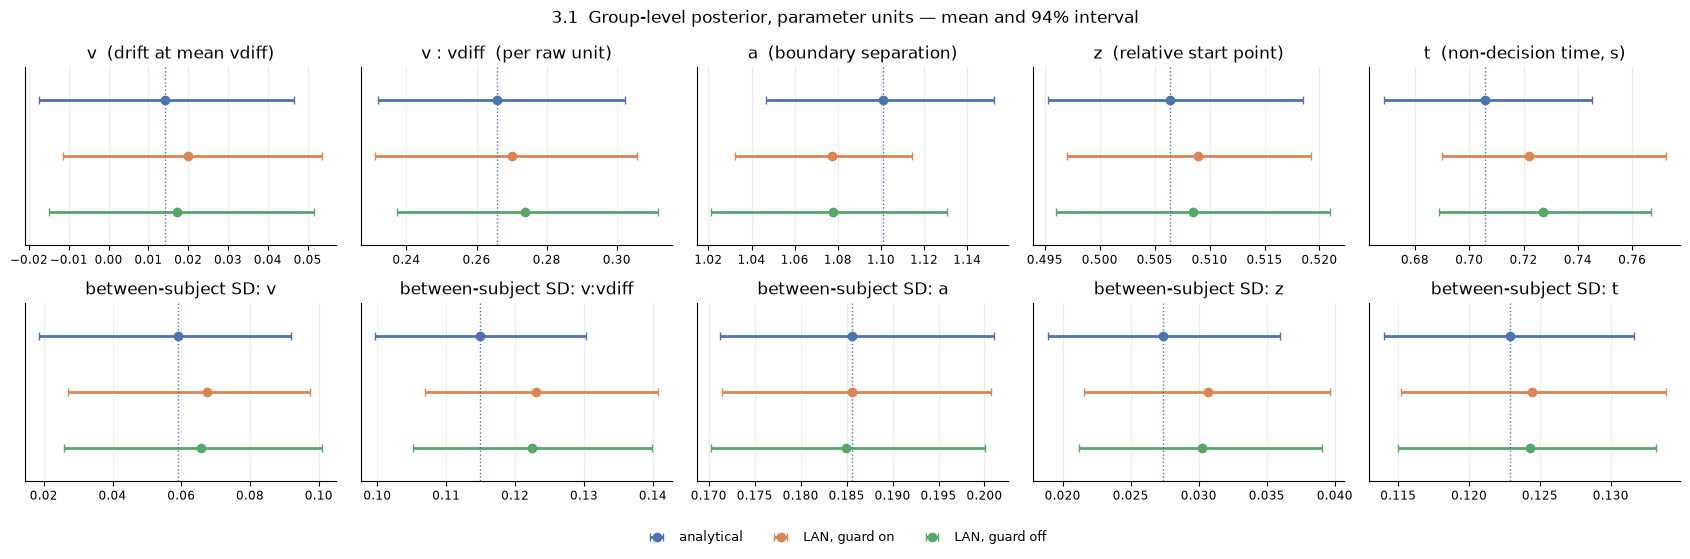

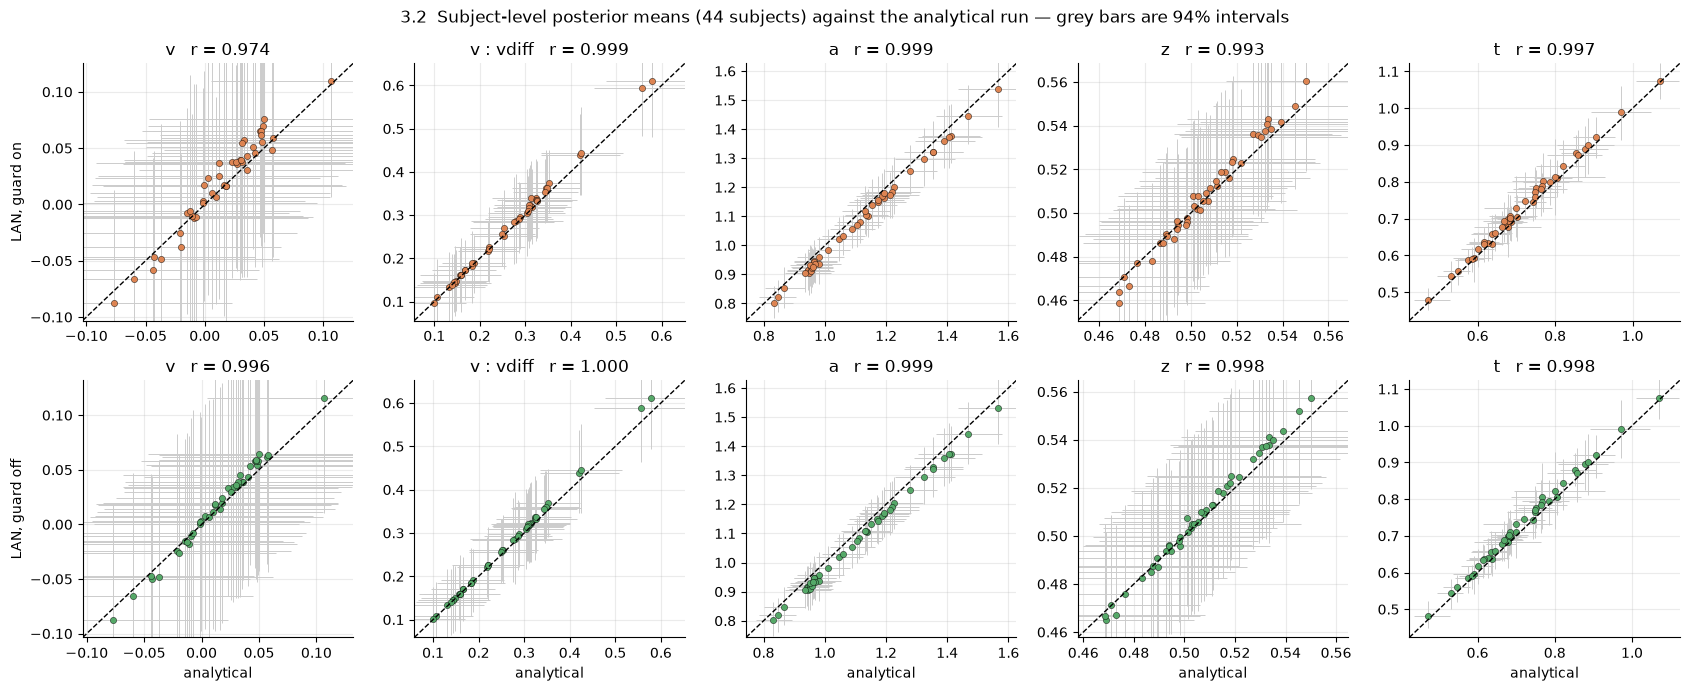

In [5]:
keys = PARAMS + [f"sd {p}" for p in PARAMS]
fig, axes = plt.subplots(2, 5, figsize=(17, 5.4))
for ax, key in zip(axes.ravel(), keys):
    for i, run in enumerate(RUNS):
        x = NAT[run][key]
        m, lo, hi = x.mean(), np.percentile(x, 3), np.percentile(x, 97)
        ax.errorbar(m, -i, xerr=[[m - lo], [hi - m]], fmt="o", ms=6, lw=2, capsize=3,
                    color=COLOR[run], label=run)
    ax.axvline(NAT["analytical"][key].mean(), color=COLOR["analytical"], ls=":", lw=1)
    ax.set(yticks=[], ylim=(-2.6, 0.6),
           title=NAMES.get(key, f"between-subject SD: {key[3:]}"))
    ax.tick_params(axis="x", labelsize=8.5)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=9, ncol=3, loc="lower center",
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle("3.1  Group-level posterior, parameter units — mean and 94% interval", fontsize=12)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(17, 7))
for row, run in enumerate(("LAN, guard on", "LAN, guard off")):
    for col, p in enumerate(PARAMS):
        ax = axes[row, col]
        ref = NAT["analytical"][f"{p}_subj"]
        est = NAT[run][f"{p}_subj"]
        rm, em = ref.mean(0), est.mean(0)
        ax.errorbar(rm, em,
                    xerr=[rm - np.percentile(ref, 3, 0), np.percentile(ref, 97, 0) - rm],
                    yerr=[em - np.percentile(est, 3, 0), np.percentile(est, 97, 0) - em],
                    fmt="none", ecolor="0.8", lw=0.7)
        ax.plot(rm, em, "o", ms=4.5, color=COLOR[run], mec="k", mew=0.3)
        lim = [min(rm.min(), em.min()), max(rm.max(), em.max())]
        pad = 0.08 * (lim[1] - lim[0])
        lim = [lim[0] - pad, lim[1] + pad]
        ax.plot(lim, lim, "k--", lw=1)
        ax.set(xlim=lim, ylim=lim,
               title=f"{NAMES[p].split('  ')[0]}   r = {np.corrcoef(rm, em)[0, 1]:.3f}",
               xlabel="analytical" if row == 1 else None,
               ylabel=run if col == 0 else None)
fig.suptitle("3.2  Subject-level posterior means (44 subjects) against the analytical run — "
             "grey bars are 94% intervals", fontsize=12)
plt.tight_layout()
plt.show()

### 3.1 Read-out

**Once the guard is removed, the LAN recovers the analytical posterior.** Subject-level
correlations with the analytical run are 0.996 or higher for every parameter, and all 44
subjects sit close to the identity line. So the LAN approximation itself is
good on this dataset. The convergence failure is not a sign that the network is a poor
approximation of the DDM.

**What remains is a small, systematic offset.** Group `t` is about 20 ms higher and group `a`
about 0.02 lower under the LAN. The guarded run already shows most of this offset (group `t`
≈ 0.722 s against 0.706 s for the analytical run), so it belongs to the network's behaviour
near the leading edge of the RT distribution rather than to removing the guard: §5 shows the
network rates trials just after `t` as more likely than the true DDM does.

The guarded run's subject estimates scatter more widely because its chains have not mixed.

## 4. Where the guard sits in HSSM's log-likelihood

The source below is read live from this checkout, so the line numbers are current.

In [6]:
def show(path, anchor, before=3, after=20):
    lines = Path(path).read_text().splitlines()
    i = next(n for n, line in enumerate(lines) if anchor in line)
    print(f"{Path(path).relative_to(Path(hssm.__file__).parents[2])}:")
    for n in range(max(0, i - before), min(len(lines), i + after)):
        print(f"{n + 1:5d}  {lines[n]}")
    print()


src = Path(hssm.__file__).parent
print("The guard:\n")
print(inspect.getsource(hssm_dist.ensure_positive_ndt))
print("Where it runs — inside the distribution's logp, BEFORE the lapse mixture:\n")
show(src / "distribution_utils" / "dist.py", "data_for_lapse = data if is_choice_only", before=8, after=25)
print("The analytical likelihood floors itself, independently of the guard:\n")
show(src / "likelihoods" / "analytical.py", "rt = rt - t", before=1, after=15)
print("Default lapse, applied when p_outlier is set and no lapse is given:\n")
show(src / "base.py", 'bmb.Prior("Uniform", lower=0.0, upper=20.0)', before=4, after=2)

The guard:

def ensure_positive_ndt(data, logp, list_params, dist_params):
    """Ensure that the non-decision time is always positive.

    Replaces the log probability of the model with a lower bound if the non-decision
    time is not positive.

    Parameters
    ----------
    data
        A two-column numpy array with response time and response.
    logp
        The log-likelihoods.
    list_params
        A list of parameters that the log-likelihood accepts. The order of the
        parameters in the list will determine the order in which the parameters
        are passed to the log-likelihood function.
    dist_params
        A list of parameters used in the likelihood computation. The parameters
        can be both scalars and arrays.

    Returns
    -------
    float
        The log-likelihood of the model.
    """
    rt = data[:, 0]

    if "t" not in list_params:
        return logp

    t = dist_params[list_params.index("t")]

    # Skip the check for missing data (encod

### 4.1 Read-out

For every trial HSSM computes, in order:

1. **the likelihood** — the analytical series or the ONNX network;
2. **`ensure_positive_ndt`** — overwrites the value with the constant `-66.1` where `rt <= t`;
3. **the lapse mixture** — `log((1 - p_outlier) * exp(logp) + p_outlier * lapse_density)`;
4. **the parameter-bounds check**.

Two details decide everything that follows.

**The guard writes a constant.** Past the wall the likelihood no longer depends on `t`, so its
gradient with respect to `t` is exactly 0 there.

**The mixture has a floor.** With the defaults, the lapse term contributes
`0.05 x (1/20) = 0.0025` to every trial's density, so no trial scores below `log(0.0025) = -5.99`.
Whether the guard changes anything *after* the mixture depends only on how far the likelihood
has already fallen when `t` reaches `rt`:

- far below `log(0.0025)` → the mixture already sits on the floor → the guard is invisible;
- not far below `log(0.0025)`, or above it → the guard moves the value → a jump, as large as
  the gap between the mixed value and the floor.

## 5. `logp` as `t` approaches `rt` — one trial

One observation: `rt = 0.80 s`, `response = +1`, with `v = 0.5`, `a = 1.2`, `z = 0.5`. Sweep `t`
from well below `rt` to just past it.

**The curves are HSSM's own log-likelihood, not a re-implementation.** They are built with
`make_distribution_for_supported_model` — the factory `HSSM` itself uses — so each value
passes through the ONNX network or analytical series, `ensure_positive_ndt`, the lapse mixture
and the bounds check exactly as in a fit. The derivative `d logp / d t` comes from
`pytensor.grad`, so it is the same gradient NUTS follows. For "guard off" the function is
patched to the identity while the graph is built, just as the `--no-ndt-guard` run did.

"Raw likelihood" means guard off *and* no lapse mixture: the bare analytical series or network
output.

In [7]:
LAPSE = bmb.Prior("Uniform", lower=0.0, upper=20.0)   # HSSM's default lapse (base.py)
P_OUTLIER = 0.05                                      # HSSM's default p_outlier
LOGP_LB = float(hssm_dist.LOGP_LB)
MIX_FLOOR = np.log(P_OUTLIER / 20.0)


def _no_guard(data, logp, list_params, dist_params):
    return logp


def hssm_logp(loglik_kind, data_rows, guard=True, lapse=True):
    """Compile HSSM's per-trial logp and d logp / d t for fixed data rows.

    Returns f(v, a, z, t) -> (logp per row, d logp / d t per row); all four arguments
    are vectors with one entry per data row.
    """
    original = hssm_dist.ensure_positive_ndt
    if not guard:
        hssm_dist.ensure_positive_ndt = _no_guard   # looked up while the graph is built
    try:
        Dist = hssm_dist.make_distribution_for_supported_model(
            "ddm", loglik_kind=loglik_kind,
            backend="jax" if loglik_kind == "approx_differentiable" else "pytensor",
            reg_params=["v", "a", "z", "t"], lapse=LAPSE if lapse else None)
        v, a, z, t = (pt.vector(name) for name in "vazt")
        rv = Dist.dist(v=v, a=a, z=z, t=t, **({"p_outlier": P_OUTLIER} if lapse else {}))
        # the lapse branch calls .eval() on the data, so it must be a constant
        lp = pm.logp(rv, pt.as_tensor(np.asarray(data_rows, float)))
        return pytensor.function([v, a, z, t], [lp, pt.grad(lp.sum(), t)])
    finally:
        hssm_dist.ensure_positive_ndt = original


CONFIGS = {  # name: (loglik_kind, guard, lapse)
    "analytical, raw likelihood": ("analytical", False, False),
    "LAN, raw likelihood": ("approx_differentiable", False, False),
    "analytical": ("analytical", True, True),
    "analytical, guard off": ("analytical", False, True),
    "LAN, guard on": ("approx_differentiable", True, True),
    "LAN, guard off": ("approx_differentiable", False, True),
}

RT, RESP, V0, A0, Z0 = 0.80, 1.0, 0.5, 1.2, 0.5
T_BEFORE = RT - np.geomspace(0.35, 1e-7, 300)                 # dense toward the wall
T_AFTER = RT + np.array([1e-7, 1e-4, 1e-3, 3e-3, 6e-3, 0.01, 0.02, 0.03, 0.04])
TGRID = np.concatenate([T_BEFORE, T_AFTER])
LAST, FIRST = len(T_BEFORE) - 1, len(T_BEFORE)                # indices either side of rt
one = np.ones(len(TGRID))
rows_trial = np.tile([RT, RESP], (len(TGRID), 1))

CURVE = {}
for name, (kind, guard, lapse) in CONFIGS.items():
    lp, grad = hssm_logp(kind, rows_trial, guard, lapse)(V0 * one, A0 * one, Z0 * one, TGRID)
    CURVE[name] = (np.asarray(lp), np.asarray(grad))

print(f"lapse-mixture floor log({P_OUTLIER}/20) = {MIX_FLOOR:.4f};  LOGP_LB = {LOGP_LB}\n")
print(f"{'':28}{'t = rt - 1e-7':>16}{'t = rt + 1e-7':>16}{'jump':>10}"
      f"{'dlogp/dt before':>18}{'after':>9}")
for name in CONFIGS:
    lp, g = CURVE[name]
    print(f"{name:28}{lp[LAST]:>16.4f}{lp[FIRST]:>16.4f}{lp[FIRST] - lp[LAST]:>+10.4f}"
          f"{g[LAST]:>18.3f}{g[FIRST]:>9.3f}")
d_an = np.abs(CURVE["analytical"][0] - CURVE["analytical, guard off"][0]).max()
print(f"\nanalytical, guard on vs off: max |logp difference| over the whole sweep = {d_an:.1e}")

lapse-mixture floor log(0.05/20) = -5.9915;  LOGP_LB = -66.1

                               t = rt - 1e-7   t = rt + 1e-7      jump   dlogp/dt before    after
analytical, raw likelihood          -67.2509        -66.1000   +1.1509             0.125    0.000
LAN, raw likelihood                  -9.1409         -9.1409   -0.0000           -89.070  -89.070
analytical                           -5.9915         -5.9915   +0.0000             0.000    0.000
analytical, guard off                -5.9915         -5.9915   +0.0000             0.000    0.000
LAN, guard on                        -5.9515         -5.9915   -0.0399            -3.486    0.000
LAN, guard off                       -5.9515         -5.9515   -0.0000            -3.486   -3.486

analytical, guard on vs off: max |logp difference| over the whole sweep = 0.0e+00


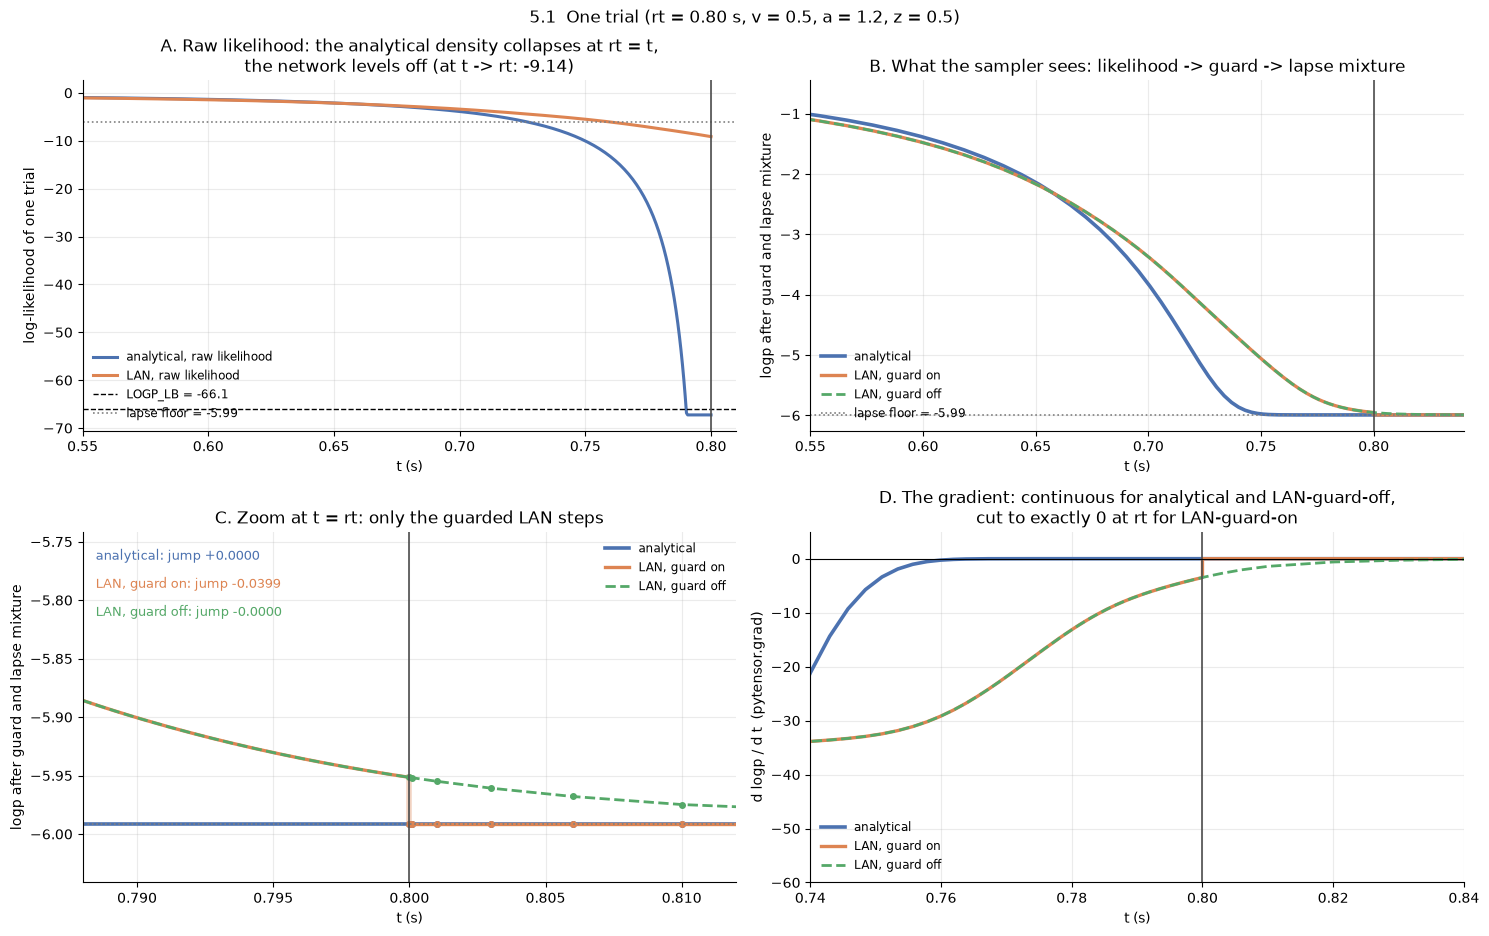

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))
before = TGRID < RT
STYLE = {"analytical": dict(color=COLOR["analytical"], lw=2.6),
         "LAN, guard on": dict(color=COLOR["LAN, guard on"], lw=2.4),
         "LAN, guard off": dict(color=COLOR["LAN, guard off"], lw=2.0, ls="--")}

# A: raw likelihood
ax = axes[0, 0]
for name, color in (("analytical, raw likelihood", COLOR["analytical"]),
                    ("LAN, raw likelihood", COLOR["LAN, guard on"])):
    ax.plot(TGRID[before], CURVE[name][0][before], color=color, lw=2.2, label=name)
ax.axhline(LOGP_LB, color="k", ls="--", lw=1, label=f"LOGP_LB = {LOGP_LB}")
ax.axhline(MIX_FLOOR, color="0.5", ls=":", lw=1.2, label=f"lapse floor = {MIX_FLOOR:.2f}")
ax.axvline(RT, color="0.3", lw=1.2)
ax.set(xlim=(0.55, RT + 0.01), xlabel="t (s)", ylabel="log-likelihood of one trial",
       title="A. Raw likelihood: the analytical density collapses at rt = t,\n"
             f"the network levels off (at t -> rt: {CURVE['LAN, raw likelihood'][0][LAST]:.2f})")
ax.legend(frameon=False, fontsize=8.5, loc="lower left")

# B: what the sampler sees
ax = axes[0, 1]
for name, style in STYLE.items():
    ax.plot(TGRID, CURVE[name][0], label=name, **style)
ax.axhline(MIX_FLOOR, color="0.5", ls=":", lw=1.2, label=f"lapse floor = {MIX_FLOOR:.2f}")
ax.axvline(RT, color="0.3", lw=1.2)
ax.set(xlim=(0.55, RT + 0.04), xlabel="t (s)", ylabel="logp after guard and lapse mixture",
       title="B. What the sampler sees: likelihood -> guard -> lapse mixture")
ax.legend(frameon=False, fontsize=8.5, loc="lower left")

# C: zoom on the wall
ax = axes[1, 0]
for name, style in STYLE.items():
    lp = CURVE[name][0]
    ax.plot(TGRID[before], lp[before], marker="", **style, label=name)
    ax.plot(TGRID[~before], lp[~before], marker="o", ms=4, **style)
    ax.plot([RT, RT], [lp[LAST], lp[FIRST]], color=style["color"], lw=4, alpha=0.35)
ax.axhline(MIX_FLOOR, color="0.5", ls=":", lw=1.2)
ax.axvline(RT, color="0.3", lw=1.2)
for k, name in enumerate(STYLE):
    lp = CURVE[name][0]
    ax.annotate(f"{name}: jump {lp[FIRST] - lp[LAST]:+.4f}", xy=(0.02, 0.92 - 0.08 * k),
                xycoords="axes fraction", color=STYLE[name]["color"], fontsize=9.5)
ax.set(xlim=(RT - 0.012, RT + 0.012), ylim=(MIX_FLOOR - 0.05, MIX_FLOOR + 0.25),
       xlabel="t (s)", ylabel="logp after guard and lapse mixture",
       title="C. Zoom at t = rt: only the guarded LAN steps")
ax.legend(frameon=False, fontsize=8.5, loc="upper right")

# D: the gradient NUTS follows
ax = axes[1, 1]
for name, style in STYLE.items():
    ax.plot(TGRID, CURVE[name][1], label=name, **style)
ax.axvline(RT, color="0.3", lw=1.2)
ax.axhline(0, color="k", lw=0.8)
ax.set(xlim=(RT - 0.06, RT + 0.04), ylim=(-60, 5), xlabel="t (s)",
       ylabel="d logp / d t  (pytensor.grad)",
       title="D. The gradient: continuous for analytical and LAN-guard-off,\n"
             "cut to exactly 0 at rt for LAN-guard-on")
ax.legend(frameon=False, fontsize=8.5, loc="lower left")
fig.suptitle("5.1  One trial (rt = 0.80 s, v = 0.5, a = 1.2, z = 0.5)", fontsize=12)
plt.tight_layout()
plt.show()

**How big is the jump elsewhere in parameter space?** Evaluate the step at the wall
(`t = rt ± 1e-7`) over a grid of drift, boundary, start point and response.

In [9]:
combos = [(v, a, z, r) for v in (-1.0, 0.0, 1.0) for a in (0.8, 1.1, 1.5)
          for z in (0.4, 0.5, 0.6) for r in (-1.0, 1.0)]
M = len(combos)
rows_grid = np.array([[RT, c[3]] for c in combos] * 2)
vv, aa, zz = (np.array([c[i] for c in combos] * 2) for i in range(3))
tt = np.concatenate([np.full(M, RT - 1e-7), np.full(M, RT + 1e-7)])

print(f"{M} combinations of v in (-1, 0, 1), a in (0.8, 1.1, 1.5), z in (0.4, 0.5, 0.6), response ±1\n")
print(f"{'':24}{'jump at the wall: min':>24}{'median':>10}{'max':>10}")
JUMPS = {}
for name in ("analytical", "LAN, guard on", "LAN, guard off"):
    kind, guard, lapse = CONFIGS[name]
    lp, _ = hssm_logp(kind, rows_grid, guard, lapse)(vv, aa, zz, tt)
    JUMPS[name] = np.asarray(lp[M:] - lp[:M])
    j = JUMPS[name]
    print(f"{name:24}{j.min():>+24.4f}{np.median(j):>+10.4f}{j.max():>+10.4f}")
lp_raw, _ = hssm_logp("approx_differentiable", rows_grid, False, False)(vv, aa, zz, tt)
edge = np.asarray(lp_raw[:M])
print(f"\nraw network output at t -> rt over the same grid: {edge.min():.2f} to {edge.max():.2f}"
      f"  (lapse floor {MIX_FLOOR:.2f})")

54 combinations of v in (-1, 0, 1), a in (0.8, 1.1, 1.5), z in (0.4, 0.5, 0.6), response ±1

                           jump at the wall: min    median       max
analytical                               +0.0000   +0.0000   +0.0000
LAN, guard on                            -2.5128   -0.0937   -0.0000
LAN, guard off                           -0.0000   -0.0000   -0.0000

raw network output at t -> rt over the same grid: -16.13 to -3.51  (lapse floor -5.99)


### 5.1 Read-out

**A — the raw likelihoods behave differently at the wall.** As `t -> rt` the analytical
density goes to zero, so its log falls without limit until its internal floor catches it at
about -67. (In the table the raw analytical value also moves by +1.15 at the wall, from that
internal floor to `LOGP_LB`; both are far below the lapse floor, so the mixture erases it.)
The network was trained on simulations where `rt > t` always holds, and a smooth tanh MLP
cannot produce a value that runs off to minus infinity, so it levels off — at -9.1 for this
trial.

**B and C — the mixture hides one of them and not the other.** The analytical log-likelihood
drops so far below the lapse floor that the mixture flattens it out *before* `t` reaches `rt`.
When the guard then fires, the value is already on the floor, so the jump is **0.0000** (and
guard on and off agree to the last bit over the whole sweep). The LAN's -9.1 is close enough
to the floor of -5.99 that, after the mixture, it still sits slightly *above* the floor
(-5.9515) when the guard fires, so the guard knocks it down by 0.04 in one step.

**D — the gradient.** For the guarded LAN, `d logp / d t` is about -3.5 just before `rt` and
exactly 0 just after — nothing in the gradient warns that the step is coming. The analytical
gradient has already gone smoothly to 0 before `rt`. The unguarded LAN stays continuous across
`rt`.

**The grid.** The analytical and unguarded-LAN jumps are 0 at every grid point. The
guarded-LAN jump ranges from about 0 to **-2.51** (median -0.094). Its size is set by where the
network levels off relative to the lapse floor. Where the network has already fallen far below
the floor (down to -16), the mixture hides it and the jump is near 0. Where the network sits
*above* the floor at the wall (up to -3.5), the guard drops the full gap. The single trial
above, with a jump of 0.04, is at the mild end of that range.

## 6. `logp` as `t` approaches `rt` — one subject from this dataset, at the fitted posterior

A single trial shows the mechanism. What the sampler actually moves, though, is each subject's
`t_j`, and every one of that subject's trials contributes a step whenever `t_j` crosses its RT.

Take the subject whose fitted `t_j` (from the converged analytical run) has the most of its
own RTs nearby. Hold that subject's `v`, `a` and `z` at their analytical posterior means,
sweep `t_j`, and sum the log-likelihood over all of the subject's trials. All three curves use
identical parameter values, so any difference comes from the likelihood and the guard alone.

In [10]:
post = NAT["analytical"]
tj_mean, tj_sd = post["t_subj"].mean(0), post["t_subj"].std(0)
rt_by_subject = {s: np.sort(data.rt[data.participant_id == s].to_numpy()) for s in SUBJECTS}
rt_min = np.array([rt_by_subject[s][0] for s in SUBJECTS])
near = np.array([((rt_by_subject[s] > tj_mean[i] - 2 * tj_sd[i]) &
                  (rt_by_subject[s] < tj_mean[i] + 2 * tj_sd[i])).sum()
                 for i, s in enumerate(SUBJECTS)])
below = np.array([(rt_by_subject[s] <= tj_mean[i]).sum() for i, s in enumerate(SUBJECTS)])

print("Analytical posterior, per subject:")
print(f"  posterior SD of t_j: median {1000 * np.median(tj_sd):.1f} ms")
print(f"  subjects whose posterior-mean t_j is ABOVE their own fastest RT: "
      f"{int((tj_mean > rt_min).sum())} / {len(SUBJECTS)}")
print(f"  trials with rt <= their subject's posterior-mean t_j: {int(below.sum())} of {len(data)}")
print(f"  subjects with at least one RT within ±2 posterior SD of t_j: "
      f"{int((near > 0).sum())} / {len(SUBJECTS)} ({int(near.sum())} trials in total)")

j = int(np.argmax(near))
SUBJ = SUBJECTS[j]
sub = data[data.participant_id == SUBJ].reset_index(drop=True)
d_an, b_an = idata["analytical"], BOUNDS["analytical"]
eta_v = (draws(d_an, "v_Intercept")[:, None] + draws(d_an, "v_1|participant_id")[:, [j]]
         + (draws(d_an, "v_vdiff")[:, None] + draws(d_an, "v_vdiff|participant_id")[:, [j]])
         * sub.vdiff_z.to_numpy()[None, :])
v_trials = inv_link(eta_v, b_an["v"]).mean(0)
a_j, z_j = post["a_subj"][:, j].mean(), post["z_subj"][:, j].mean()
print(f"\nsubject {SUBJ}: {len(sub)} trials, fastest RTs {np.round(rt_by_subject[SUBJ][:5], 3)}")
print(f"  analytical posterior: t_j = {tj_mean[j]:.4f} ± {tj_sd[j]:.4f} s, a = {a_j:.3f}, z = {z_j:.3f}")
print(f"  RTs within ±2 SD of t_j: {int(near[j])}")

T_SWEEP = np.linspace(rt_min[j] - 0.10, tj_mean[j] + 3 * tj_sd[j], 700)
n, k = len(sub), len(T_SWEEP)
rows_subj = np.tile(sub[["rt", "response"]].to_numpy(float), (k, 1))
V = np.tile(v_trials, k)
A, Z = np.full(n * k, a_j), np.full(n * k, z_j)
T = np.repeat(T_SWEEP, n)

SUBJ_CURVE = {}
for name in ("analytical", "LAN, guard on", "LAN, guard off"):
    kind, guard, lapse = CONFIGS[name]
    lp, g = hssm_logp(kind, rows_subj, guard, lapse)(V, A, Z, T)
    SUBJ_CURVE[name] = (np.asarray(lp).reshape(k, n).sum(1), np.asarray(g).reshape(k, n).sum(1))

print("\nstep in the subject's summed logp as t_j crosses each of its three fastest RTs"
      " (rt + 1e-7 minus rt - 1e-7):")
SUBJ_STEPS = {}
for name in SUBJ_CURVE:
    kind, guard, lapse = CONFIGS[name]
    f = hssm_logp(kind, np.tile(sub[["rt", "response"]].to_numpy(float), (2, 1)), guard, lapse)
    steps = []
    for r in rt_by_subject[SUBJ][:3]:
        tpair = np.repeat([r - 1e-7, r + 1e-7], n)
        lp, _ = f(np.tile(v_trials, 2), np.full(2 * n, a_j), np.full(2 * n, z_j), tpair)
        lp = np.asarray(lp).reshape(2, n).sum(1)
        steps.append(lp[1] - lp[0])
    SUBJ_STEPS[name] = np.array(steps)
    print(f"  {name:16}" + "   ".join(f"at {r:.3f}: {s:+.4f}" for r, s in zip(rt_by_subject[SUBJ][:3], steps)))

Analytical posterior, per subject:
  posterior SD of t_j: median 25.9 ms
  subjects whose posterior-mean t_j is ABOVE their own fastest RT: 9 / 44
  trials with rt <= their subject's posterior-mean t_j: 10 of 8427
  subjects with at least one RT within ±2 posterior SD of t_j: 16 / 44 (21 trials in total)

subject 14: 200 trials, fastest RTs [0.634 0.684 0.734 0.767 0.783]
  analytical posterior: t_j = 0.6766 ± 0.0229 s, a = 0.953, z = 0.550
  RTs within ±2 SD of t_j: 2

step in the subject's summed logp as t_j crosses each of its three fastest RTs (rt + 1e-7 minus rt - 1e-7):
  analytical      at 0.634: +0.0000   at 0.684: -0.0000   at 0.734: -0.0001
  LAN, guard on   at 0.634: -0.3887   at 0.684: -0.4642   at 0.734: -0.6441
  LAN, guard off  at 0.634: +0.0000   at 0.684: -0.0000   at 0.734: -0.0000


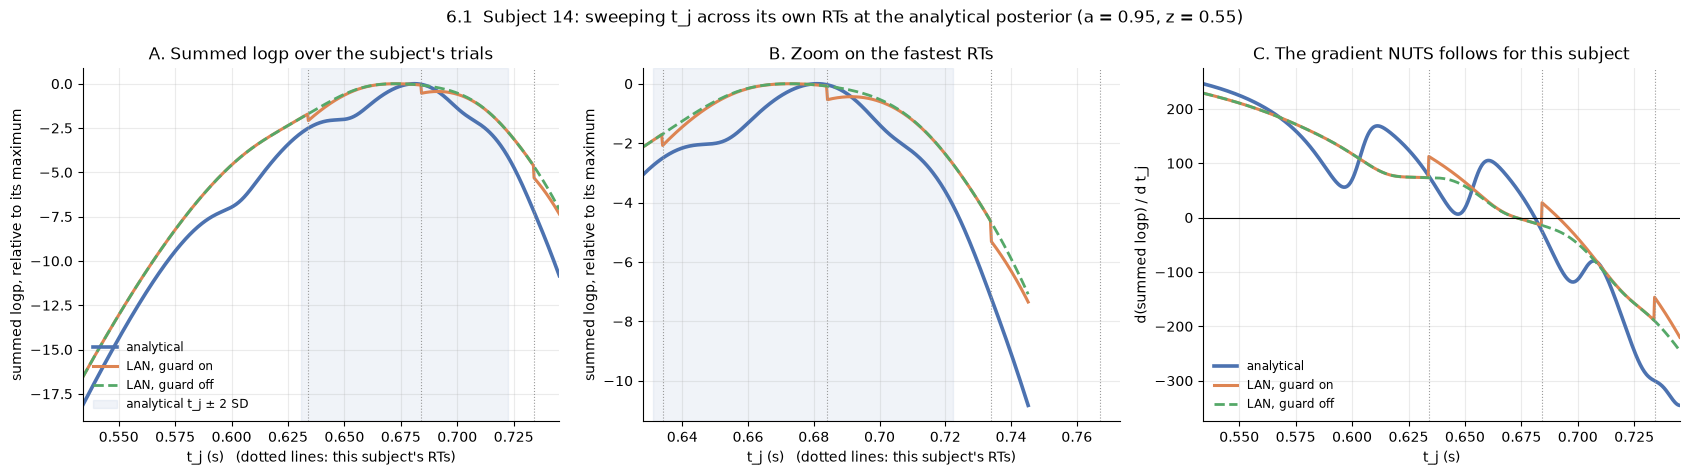

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
style = {"analytical": dict(color=COLOR["analytical"], lw=2.6),
         "LAN, guard on": dict(color=COLOR["LAN, guard on"], lw=2.2),
         "LAN, guard off": dict(color=COLOR["LAN, guard off"], lw=2.0, ls="--")}
rts = rt_by_subject[SUBJ]

for ax, (lo, hi), ttl in ((axes[0], (T_SWEEP[0], T_SWEEP[-1]), "A. Summed logp over the subject's trials"),
                          (axes[1], (rts[0] - 0.006, rts[min(3, len(rts) - 1)] + 0.006),
                           "B. Zoom on the fastest RTs")):
    sel = (T_SWEEP >= lo) & (T_SWEEP <= hi)
    for name, st in style.items():
        L = SUBJ_CURVE[name][0]
        ax.plot(T_SWEEP[sel], L[sel] - L[sel].max(), label=name, **st)
    for r in rts[(rts >= lo) & (rts <= hi)]:
        ax.axvline(r, color="0.6", lw=0.8, ls=":")
    ax.axvspan(tj_mean[j] - 2 * tj_sd[j], tj_mean[j] + 2 * tj_sd[j], color=COLOR["analytical"],
               alpha=0.08, label="analytical t_j ± 2 SD")
    ax.set(xlim=(lo, hi), xlabel="t_j (s)   (dotted lines: this subject's RTs)",
           ylabel="summed logp, relative to its maximum", title=ttl)
axes[0].legend(frameon=False, fontsize=8.5, loc="lower left")

ax = axes[2]
for name, st in style.items():
    ax.plot(T_SWEEP, SUBJ_CURVE[name][1], label=name, **st)
for r in rts[rts <= T_SWEEP[-1]]:
    ax.axvline(r, color="0.6", lw=0.8, ls=":")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlim=(T_SWEEP[0], T_SWEEP[-1]), xlabel="t_j (s)", ylabel="d(summed logp) / d t_j",
       title="C. The gradient NUTS follows for this subject")
ax.legend(frameon=False, fontsize=8.5, loc="lower left")
fig.suptitle(f"6.1  Subject {SUBJ}: sweeping t_j across its own RTs at the analytical posterior "
             f"(a = {a_j:.2f}, z = {z_j:.2f})", fontsize=12)
plt.tight_layout()
plt.show()

### 6.1 Read-out

**The guarded LAN has steps; the other two do not.** At each of this subject's fastest RTs, the
guarded LAN's summed log-likelihood drops by 0.39, 0.46 and 0.64 in a single step, and its
gradient jumps upward at the same points (panel C) — the crossed trial stops contributing any
gradient at all. The analytical and unguarded-LAN curves pass through the same RTs continuously.
(The analytical step of -0.0001 at 0.734 is just its ordinary slope over the 2e-7 window, not a
jump.)

**These RTs are where the posterior lives.** Two of them fall inside the analytical posterior's
±2 SD range for `t_j` (shaded), and this subject's posterior-mean `t_j` (0.677 s) is *above* its
fastest RT (0.634 s). A sampler exploring this posterior crosses them constantly.

**The analytical curve is sharper but still smooth.** It is more strongly peaked than either
LAN curve, with bumps in the value and gradient a few tens of milliseconds before each RT. Those
bumps are each trial's density collapsing steeply but continuously toward the floor — the same
behaviour the network smooths over. Steep, smooth features like these are what NUTS handles
well; the analytical run adapts to a step size of 0.11. The peaks of all three curves are in
about the same place, consistent with the posterior agreement in §3.

## 7. Why a jump stalls NUTS, and how much this dataset is exposed to it

**Leapfrog energy error.** NUTS proposes moves by simulating a trajectory on the potential
`U = -log posterior` with a leapfrog integrator of step size `eps`, and accepts with
probability about `exp(-dH)`, where `dH` is the integrator's energy error. Step-size
adaptation tunes `eps` until the average acceptance equals `target_accept = 0.8`, which means
it aims for `dH ≈ -log(0.8) = 0.22`.

**Smooth potentials.** The energy error shrinks like `eps^2`, so a smaller step can always
buy accuracy, however steep the posterior.

**A jump is different.** The gradient is finite and identical on both sides of the step, so
the integrator steps straight across it, `U` changes instantly, and the momentum never adjusts.
The whole jump lands in `dH`, **however small `eps` is**. The only thing a smaller step size
achieves is fewer crossings per unit of simulated time.

That is exactly the signature in §2:

- adaptation drove `eps` down ~150×;
- trajectories then needed the full 1,023 steps to travel anywhere, so every draw hit
  `max_tree_depth`;
- successive draws barely moved, so ESS collapsed;
- and no single trajectory's energy error ever came close to the divergence threshold, so
  there were **no divergences**.

In [12]:
budget = -np.log(0.8)
lan = np.abs(JUMPS["LAN, guard on"])
print(f"dH budget at target_accept = 0.8: {budget:.3f}\n")
print("size of one guarded-LAN crossing, relative to that budget:")
print(f"  §5 grid ({len(lan)} parameter combinations): median {np.median(lan):.3f} "
      f"({np.median(lan) / budget:.1f}x budget), largest {lan.max():.3f} ({lan.max() / budget:.1f}x); "
      f"{(lan > budget).mean():.0%} of combinations exceed the whole budget")
subj = np.abs(SUBJ_STEPS["LAN, guard on"])
print(f"  subject {SUBJ}, three fastest RTs: " + ", ".join(f"{s:.2f} ({s / budget:.1f}x)" for s in subj))

steps = {run: float(np.asarray(idata[run].sample_stats.step_size.values)[:, -1].mean()) for run in RUNS}
print("\nadapted step size: " + " | ".join(f"{r} {s:.2e}" for r, s in steps.items()))
print(f"  guard on / guard off = 1 / {steps['LAN, guard off'] / steps['LAN, guard on']:.0f}")

# exposure after warmup: RTs inside each subject's posterior range for t_j (from §6)
print(f"\nafter warmup: {int((near > 0).sum())} of {len(SUBJECTS)} subjects have RTs within ±2 posterior SD"
      f" of t_j ({int(near.sum())} RTs in total lie inside those ranges)")

# exposure during warmup: HSSM starts t far below every RT
eta0 = INITVAL_SETTINGS["log_logit"]["t_Intercept"]
t0_lan = inv_link(eta0, BOUNDS["LAN, guard on"]["t"])
t_group = NAT["analytical"]["t"].mean()
print(f"during warmup: HSSM's default initial value t_Intercept = {eta0} on the link scale"
      f" -> t = {t0_lan:.3f} s for the LAN's (0, 2) logit link.")
print(f"  moving the group t up to its posterior value ({t_group:.3f} s) passes "
      f"{int((data.rt < t_group).sum())} trials whose rt is below it — each a step of the kind above,"
      f"\n  crossed while the step size is being adapted.")

dH budget at target_accept = 0.8: 0.223

size of one guarded-LAN crossing, relative to that budget:
  §5 grid (54 parameter combinations): median 0.094 (0.4x budget), largest 2.513 (11.3x); 33% of combinations exceed the whole budget
  subject 14, three fastest RTs: 0.39 (1.7x), 0.46 (2.1x), 0.64 (2.9x)

adapted step size: analytical 1.09e-01 | LAN, guard on 7.60e-04 | LAN, guard off 1.24e-01
  guard on / guard off = 1 / 163

after warmup: 16 of 44 subjects have RTs within ±2 posterior SD of t_j (21 RTs in total lie inside those ranges)
during warmup: HSSM's default initial value t_Intercept = -4.0 on the link scale -> t = 0.036 s for the LAN's (0, 2) logit link.
  moving the group t up to its posterior value (0.706 s) passes 62 trials whose rt is below it — each a step of the kind above,
  crossed while the step size is being adapted.


### 7.1 Read-out

A single crossing can cost anything from nothing to about eleven times the whole `dH` budget,
delivered in one instantaneous step. On the §5 grid the median cost is 0.4 times the budget, and
a third of the parameter combinations exceed the whole budget in a single crossing. At subject
14's fastest RTs each crossing costs 1.7–2.9 times the budget. Only a handful of
subjects' RTs sit inside the posterior range of `t_j`, but NUTS trajectories run for hundreds of
steps, so they are crossed routinely. During warmup
the exposure is much larger: `t` starts far below every RT and must climb through the lower
tail of the RT distribution while the step size is being tuned. The step size that comes out
of warmup is then used for all 1,000 draws.

Remove the discontinuity and all of this goes away, leaving the likelihood itself untouched:
the unguarded LAN adapts to a step size of 0.12, like the analytical run.

For a direct measurement of `dH` against step size on the full hierarchical model (guard on
and off, analytical and LAN), see §11 of `ddm_data_comparison.ipynb` in this folder.

## 8. Summary for developers

**The bug.** `ensure_positive_ndt` enforces `t < rt` by overwriting the log-likelihood with the
constant `LOGP_LB` *before* the lapse mixture. For any likelihood that has not already fallen
far below the lapse floor by the time `t` reaches `rt`, this makes the log-posterior
**discontinuous in `t`** at every observed RT, and cuts the gradient to exactly 0 past the
wall. HMC/NUTS cannot integrate across the step; adaptation responds by collapsing the step
size, with no divergences to flag it.

**Who is affected.**

- *Analytical likelihoods are not.* `logp_ddm` enforces the constraint itself and its density
  has already underflowed, so the guard is a no-op (§5: identical to the last bit, guard on or
  off).
- *LANs are.* `approx_differentiable` models with a `t` parameter are affected, because the
  network cannot represent the density vanishing at `rt = t` and levels off at a finite value
  that is often not far below the lapse floor, or above it.
- *Hierarchical fits make it worse.* Some subjects' `t_j` legitimately sits near their fastest
  RTs, so the sampler lives on the staircase (§6–7).
- *`p_outlier` changes the size, not the existence.* The jump is the gap between the network's
  level at the wall and the floor `log(p_outlier / lapse_range)`: a higher `p_outlier` lifts
  the floor and shrinks the jump, while `p_outlier = None` removes the floor and makes the jump
  the full distance down to -66.1.

## Files in this folder

| file | what it is |
|---|---|
| `ndt_guard_bug.ipynb` | this notebook |
| `idata/*.nc` | the three runs compared here |
| `ddm_ladder_real_data.csv` | the dataset (8,427 trials, 44 subjects) |
| `ddm_mre_hierarchical_james (1).py` | the script that produced the runs (`--no-ndt-guard` for the third) |
| `run_ddm_mre_hierarchical_james (1).sh` | SLURM wrapper (`NDT_GUARD=off`) |
| `ddm_data_comparison.ipynb` | the longer investigation, including the `dH` measurements |
| `ndt_guard_dh_precompute.py` | precompute for those `dH` measurements |